### Importing dependencies

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

### Data Collection & Pre-Processing

In [7]:
# loading data from csv file into pandas DataFrame
raw_mail_data = pd.read_csv('mail_data.csv')

In [19]:
# replace null values with null string
mail_data = raw_mail_data.where(pd.notnull(raw_mail_data), '')

In [20]:
# printing first 5 rows
mail_data.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [21]:
# Checking number of rows and columns of dataset
mail_data.shape

(5572, 2)

### Label Encoding

In [23]:
# label spam mail as 0 ; ham mail as 1
mail_data['Category'] = mail_data['Category'].replace({'spam':0,'ham':1}).astype(int)

In [24]:
# separating data as texts and labels
X = mail_data['Message']
y = mail_data['Category']

In [25]:
X

0       Go until jurong point, crazy.. Available only ...
1                           Ok lar... Joking wif u oni...
2       Free entry in 2 a wkly comp to win FA Cup fina...
3       U dun say so early hor... U c already then say...
4       Nah I don't think he goes to usf, he lives aro...
                              ...                        
5567    This is the 2nd time we have tried 2 contact u...
5568                 Will ü b going to esplanade fr home?
5569    Pity, * was in mood for that. So...any other s...
5570    The guy did some bitching but I acted like i'd...
5571                           Rofl. Its true to its name
Name: Message, Length: 5572, dtype: object

In [26]:
y

0       1
1       1
2       0
3       1
4       1
       ..
5567    0
5568    1
5569    1
5570    1
5571    1
Name: Category, Length: 5572, dtype: int64

### splitting data into training data and test data

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,stratify=y, random_state=3)

In [29]:
print(X.shape,X_train.shape, X_test.shape)

(5572,) (4457,) (1115,)


### Feature Extraction

In [30]:
# Transform text data to feature vectors that can be used as input to Logistic Regression model
feature_extraction = TfidfVectorizer(min_df=1, lowercase=True, stop_words='english')
X_train_features = feature_extraction.fit_transform(X_train)
X_test_features = feature_extraction.transform(X_test)

In [32]:
print(X_train_features)

### Training the model
#### Logistic  Regression

In [33]:
model = LogisticRegression()
# training logistic regression model
model.fit(X_train_features, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


### Evaluating the trained model

In [39]:
# prediction on training data
y_train_pred = model.predict(X_train_features)
accuracy_on_training_data = accuracy_score(y_train, y_train_pred)
print("Accuracy on training data:", accuracy_on_training_data)

Accuracy on training data: 0.9667938074938299


In [41]:
# prediction on test data
y_test_pred = model.predict(X_test_features)
accuracy_on_test_data = accuracy_score(y_test, y_test_pred)
print("Accuracy on test data:",accuracy_on_test_data)

Accuracy on test data: 0.9713004484304932


In [42]:
model.score(X_test_features, y_test)

0.9713004484304932

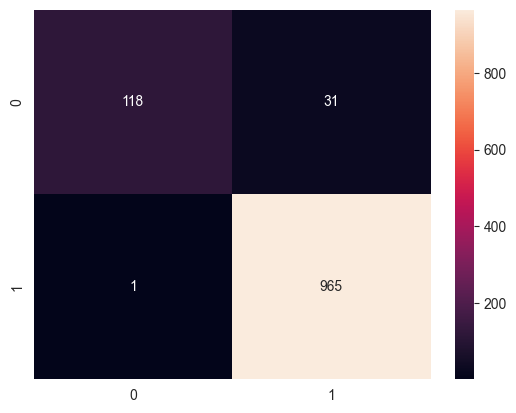

In [47]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.show()

In [48]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.99      0.79      0.88       149
           1       0.97      1.00      0.98       966

    accuracy                           0.97      1115
   macro avg       0.98      0.90      0.93      1115
weighted avg       0.97      0.97      0.97      1115



### Building a Predictive System

In [46]:
input_mail = ['Ive been searching for the right words to thank you for this breather. I promise i wont take your help for granted and will fulfil my promise. You have been wonderful and a blessing at all times.']
input_data_features=feature_extraction.transform(input_mail)
prediction = model.predict(input_data_features)
print(prediction)
if prediction[0]== 0:
    print("It is a spam")
else:
    print("It is a ham")

[1]
It is a ham
